# 2: Exploratory Data Analysis

Explore the processed dataset, understand ridership patterns across temporal, geographic, weather, and behavioral dimensions. Each visualization gives insight to a specific inquiry about what drives Citibike demand

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

## 2.1: Setup

Load processed data, and set up plot styling, other prerequisites

In [2]:
# load processed data
df_model = pd.read_csv('../data/processed/hourly_merged.csv', parse_dates=['start_hour'])
df = pd.read_csv('../data/processed/hourly_by_rideable_type.csv', parse_dates=['start_hour'])
station_lookup = pd.read_csv('../data/processed/station_lookup.csv')
df['hour_of_day'] = df['start_hour'].dt.hour # done ahead of time for rideable type analysis

# spatial-based data setup
station_stats = (df_model.groupby('start_station_id')
				.agg(avg_ride_count=('ride_count', 'mean'),
					total_traffic=('total_traffic', 'sum'))
				.reset_index())

stations_geo = gpd.GeoDataFrame(
	station_lookup.merge(station_stats, on='start_station_id', how='left'),
    geometry=gpd.points_from_xy(station_lookup['start_lng'], station_lookup['start_lat']),
	crs='EPSG:4326')

nta = gpd.read_file('../data/raw/spatial/nta.shp')

# plot styling
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

COLORS = {
	'primary': '#2563EB',
	'secondary': '#F59E0B', 
	'accent': '#10B981',
	'muted': '#94A3B8'
}

C:\Users\Kacp3r\AppData\Local\Temp\ipykernel_12820\3522653065.py:2: DtypeWarning: Columns (0: start_station_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df_model = pd.read_csv('../data/processed/hourly_merged.csv', parse_dates=['start_hour'])
C:\Users\Kacp3r\AppData\Local\Temp\ipykernel_12820\3522653065.py:3: DtypeWarning: Columns (0: start_station_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/processed/hourly_by_rideable_type.csv', parse_dates=['start_hour'])


## 2.2: Daily Ridership

Total daily departures across the full 3-month period. Shows overall trend in ridership and day-to-day variance. The point of interest observed here is the flattening out of ridership in June. The two lowest days in April correspond to a cold and rainy weather outlier event, that will be seen down the line in the weather analysis

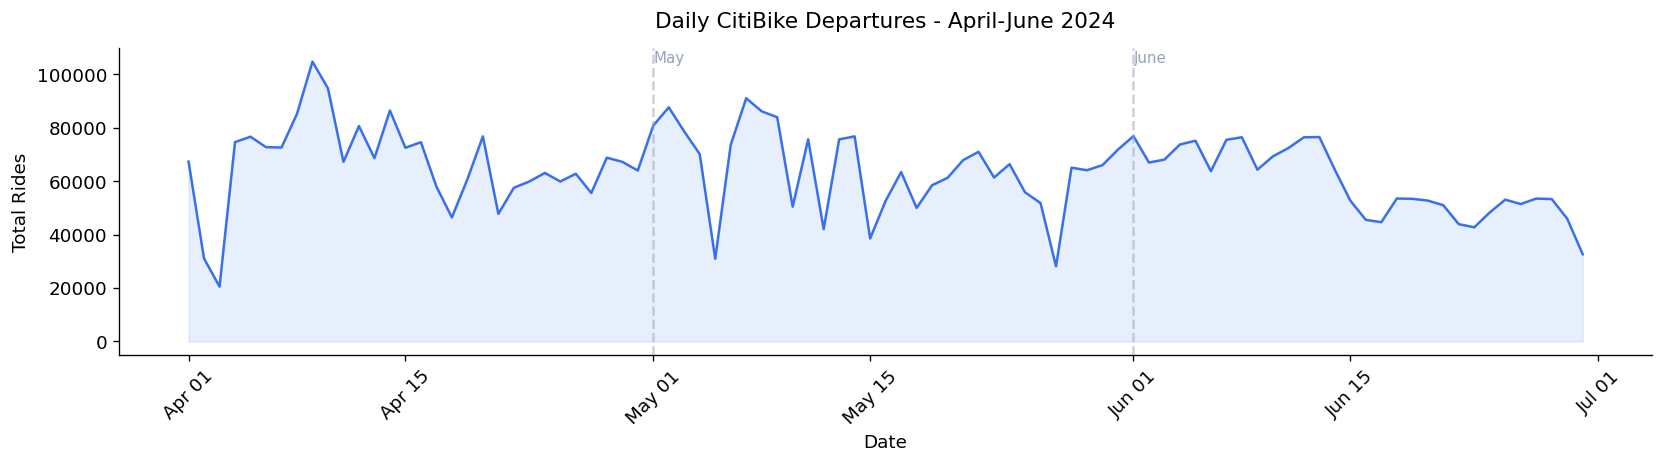

In [3]:
# initialize dataframe for daily ridership
daily = (df_model.groupby(df_model['start_hour'].dt.date)['ride_count']
		.sum()
		.reset_index())
daily.columns = ['date', 'total_rides']
daily['date'] = pd.to_datetime(daily['date'])

# initialize plot
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily['date'], daily['total_rides'], color=COLORS['primary'], linewidth=1.5, alpha=0.9)
ax.fill_between(daily['date'], daily['total_rides'], alpha=0.1, color=COLORS['primary'])

# label month boundaries
for month_start in ['2024-05-01', '2024-06-01']:
    ax.axvline(pd.Timestamp(month_start), color=COLORS['muted'], linestyle='--', alpha=0.5)
    ax.text(pd.Timestamp(month_start), ax.get_ylim()[1]*0.95, pd.Timestamp(month_start).strftime('%B'), 
            ha='left', fontsize=9, color=COLORS['muted'])

# plot configuration and display
ax.set_title('Daily CitiBike Departures - April-June 2024', fontsize=13, pad=12)
ax.set_xlabel('Date')
ax.set_ylabel('Total Rides')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../figures/eda/daily_ridership_timeseries.png', bbox_inches='tight')
plt.show()

## 2.3: Hourly Ridership

Average hourly departures per station split by weekday and weekend. The weekday double hump reflects commuter behavior during rush hour (morning and afternoon window denoted by a light gray box). The weekday single midday peak likely reflects more leisurely riding, compared to the work commutes driving the double humps on weekdays.

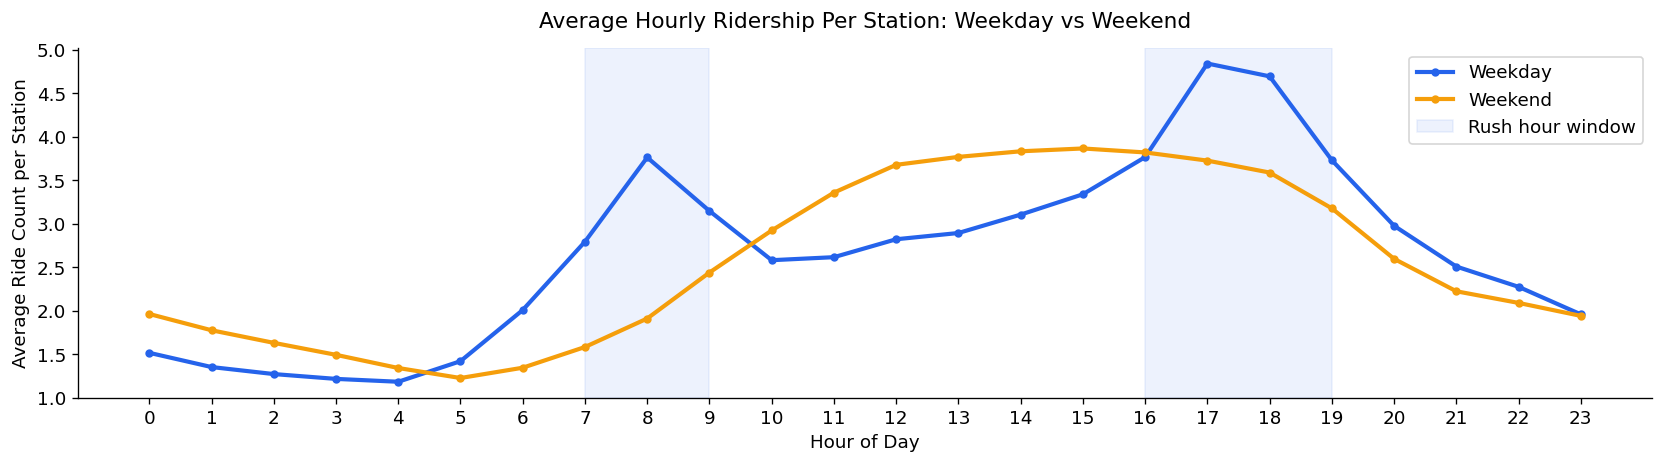

In [4]:
# initialize dataframe for hourly ridership, separating weekday vs weekend ridership
hourly_weekday = (df_model[df_model['is_weekend'] == 0].groupby('hour_of_day')['ride_count'].mean())
hourly_weekend = (df_model[df_model['is_weekend'] == 1].groupby('hour_of_day')['ride_count'].mean())

# initialize plot
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(hourly_weekday.index, hourly_weekday.values, color=COLORS['primary'], 
    linewidth=2.5, label="Weekday", marker="o", markersize=4)
ax.plot(hourly_weekend.index, hourly_weekend.values, color=COLORS['secondary'], 
    linewidth=2.5, label="Weekend", marker="o", markersize=4)

# visually indicate rush hour windows (7-9 AM, 4-7 PM)
ax.axvspan(7, 9, alpha=0.08, color=COLORS['primary'], label='Rush hour window')
ax.axvspan(16, 19, alpha=0.08, color=COLORS['primary'])

# plot configuration and display
ax.set_title('Average Hourly Ridership Per Station: Weekday vs Weekend', fontsize=13, pad=12)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Ride Count per Station')
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.savefig('../figures/eda/hourly_weekday_vs_weekend.png', bbox_inches='tight')
plt.show()

## 2.4: Ridership by Day of Week

Average departures per station by day. Weekdays consistently outperform weekend, with Tuesday as the highest day and Sunday the lowest, although the gap between weekday and weekends is modest, again likely reflecting a period of leisurely riding to offset the loss in commuter-based riding

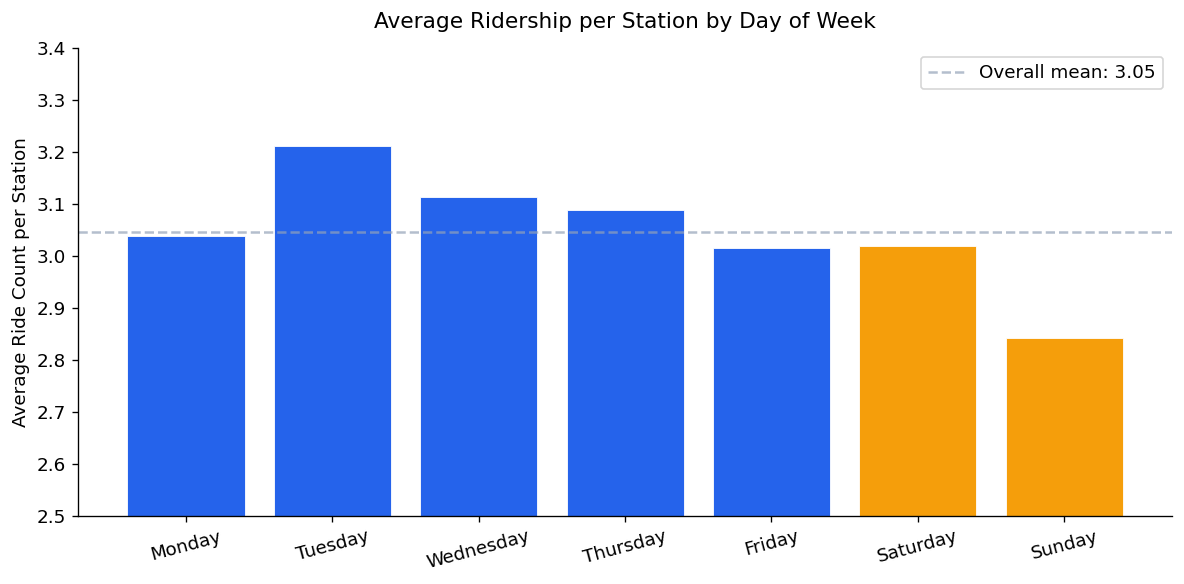

In [5]:
# initialize dataframe for week-based ridership
dow_avg = df_model.groupby('day_of_week')['ride_count'].mean()
day_labels = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# initialize plot
colors = [COLORS['secondary'] if i >= 5 else COLORS['primary'] for i in range(7)]
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(day_labels, dow_avg.values, color=colors, edgecolor='white', linewidth=0.5)
ax.axhline(dow_avg.mean(), color=COLORS['muted'], linestyle='--', alpha=0.7, label=f"Overall mean: {dow_avg.mean():.2f}")

# plot configuration and display
ax.set_title('Average Ridership per Station by Day of Week', fontsize=13, pad=12)
ax.set_ylabel('Average Ride Count per Station')
ax.set_ylim(2.5, 3.4)
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../figures/eda/ridership_by_day_of_week.png', bbox_inches='tight')
plt.show()

## 2.5: Ridership by Borough

Total CitiBike traffic (departures + arrivals) aggregated by borough. Manhattan dominates by a wide margin, roughly 3x as much as distant-second Brooklyn. This concentration represents a trend apparent throughout the rest of this project, as network density and higher per-station demand increase ridership counts in Manhattan's core

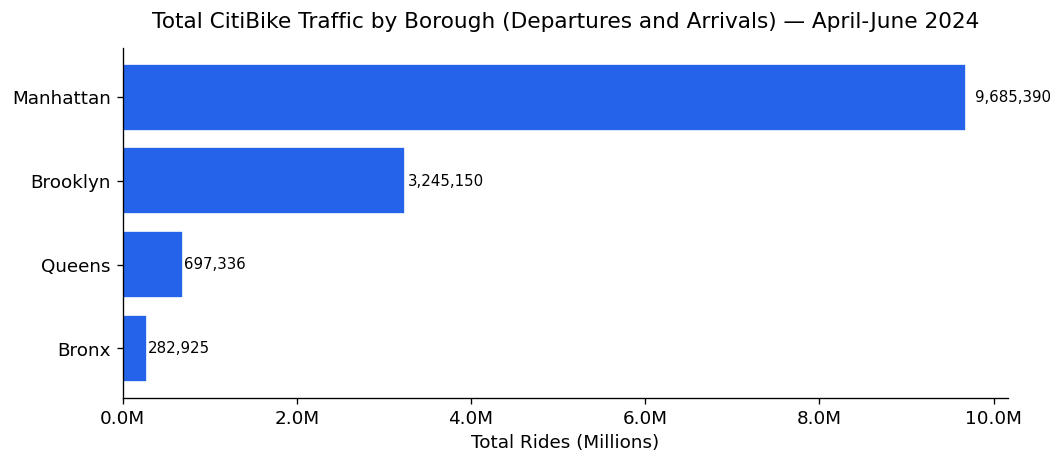

In [6]:
# initialize dataframe
boro_total = (df_model.groupby('boroname')['total_traffic']
			.sum()
			.sort_values(ascending=True))

# initialize plot, add corresponding value labels on bars
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(boro_total.index, boro_total.values, color=COLORS['primary'], edgecolor='white')

for bar, val in zip(bars, boro_total.values):
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2, f"{val:,.0f}", va="center", fontsize=9)

# plot configuration and display
ax.set_title('Total CitiBike Traffic by Borough (Departures and Arrivals) — April-June 2024', fontsize=13, pad=12)
ax.set_xlabel('Total Rides (Millions)')
ax.xaxis.set_major_formatter(
	plt.FuncFormatter(lambda x, p: f"{x/1e6:.1f}M")
) # scale values down to reflect x axis scale
plt.tight_layout()
plt.savefig('../figures/eda/ridership_by_borough.png', bbox_inches='tight')
plt.show()

## 2.6: Top Neighborhoods by Ridership

Neighborhood-level traffic breakdown showing where demand is actually concentrated. As will be shown later through maps, Chelsea-Hudson Yards leads all neighborhoods. 14 of the top 15 are in Manhattan, with Williamsburg being the only entry outside of Manhattan. A preview to the choropleth map down the line

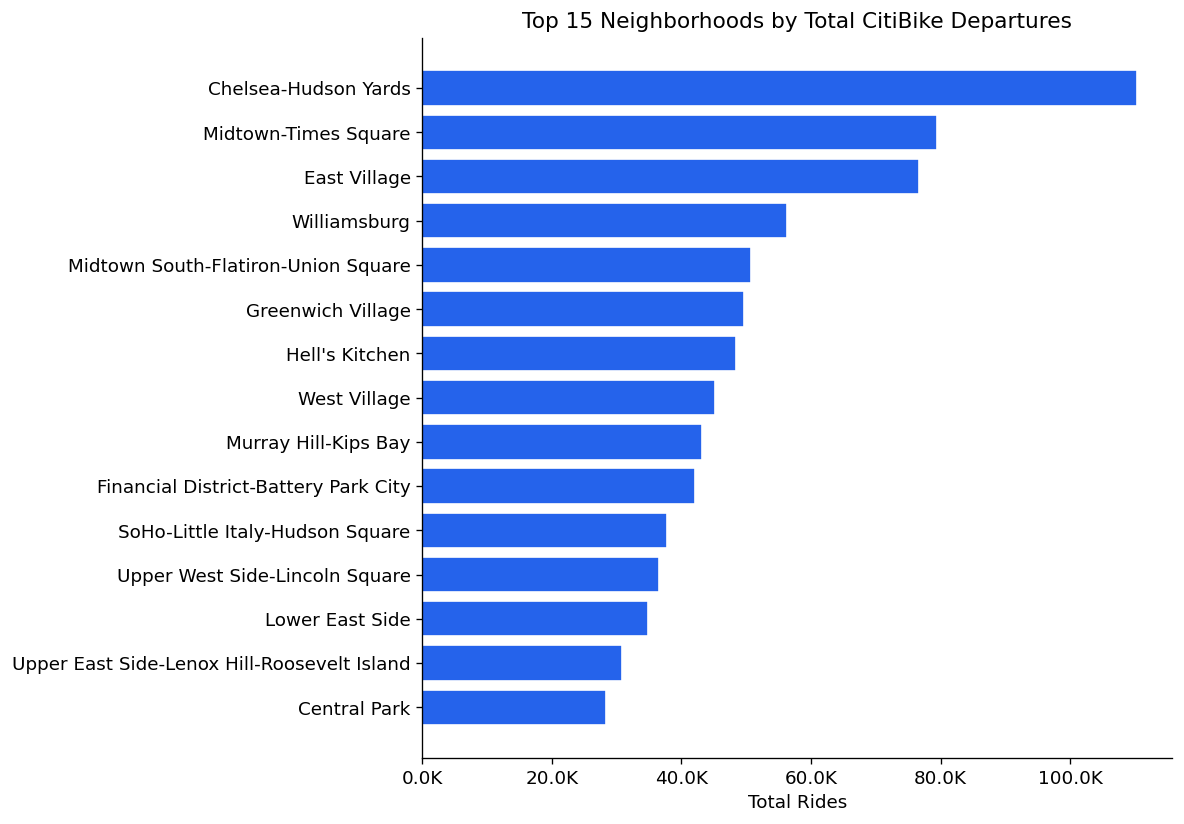

In [7]:
# initialize dataframe
nta_total = (df_model.groupby('ntaname')['total_traffic']
			.sum()
			.sort_values(ascending=True)
			.tail(15))

# initialize, configure and display plot
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(nta_total.index, nta_total.values, color=COLORS['primary'], edgecolor='white')
ax.set_title('Top 15 Neighborhoods by Total CitiBike Departures', fontsize=13)
ax.set_xlabel('Total Rides')
ax.xaxis.set_major_formatter(
	plt.FuncFormatter(lambda x, p: f"{x/1e4}K")
) # scale values down to reflect x axis scale

plt.tight_layout()
plt.savefig('../figures/eda/top_neighborhoods_ridership.png', bbox_inches='tight')
plt.show()

## 2.7: Weather Relationships

Weather analysis conducted at the daily aggregate level, where effects are most visible. 

- Left: temperature vs ridership colored by dry/rainy day status. 
- Center: precipitation scatter with negative regression line
- Right: dry vs rainy day distribution showing a reduction in mean ridership on rainy days.

Weather effects are substantially weaker at the hourly station level. Weather influences the decision to ride at all more than which station or hour riders choose within a riding day

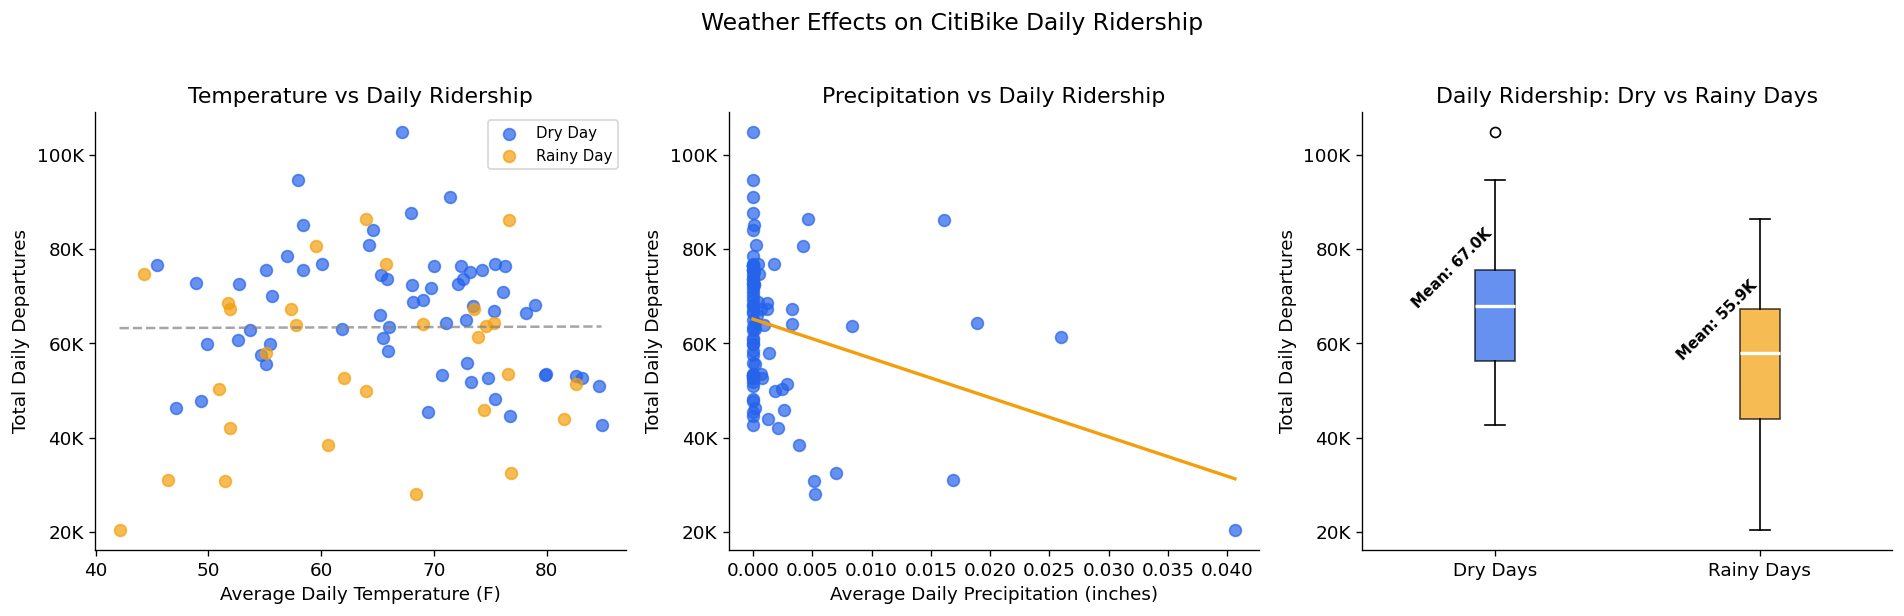

Dry day mean ridership:   66,964
Rainy day mean ridership: 55,941
Rain reduction:           16.5%
Temp correlation with daily ridership: 0.006
Precip correlation with daily ridership: -0.318


In [8]:
# initialize dataframe, aggregate for weather on a given day
daily_weather = (df_model.groupby(df_model['start_hour'].dt.date)
				.agg(total_rides=('ride_count', 'sum'),
					avg_temp=('HourlyDryBulbTemperature', 'mean'),
					avg_precip=('HourlyPrecipitation', 'mean'))
				.reset_index())
daily_weather['date'] = pd.to_datetime(daily_weather['start_hour'])
daily_weather['is_rainy'] = (daily_weather['avg_precip'] > 0.0005).astype(int)

fig, ax = plt.subplots(1, 3, figsize=(16, 5))

# temperature vs ridership
# assign proper labels and colors to rainy vs non-rainy data 
for is_rainy, color, label in [(0, COLORS['primary'], 'Dry Day'), (1, COLORS['secondary'], 'Rainy Day')]:
    mask = daily_weather['is_rainy'] == is_rainy
    ax[0].scatter(daily_weather[mask]['avg_temp'], daily_weather[mask]['total_rides'],
                alpha=0.7, color=color, s=50, label=label)

# fit regression line across all days
z = np.polyfit(daily_weather['avg_temp'], daily_weather['total_rides'], 1)
p = np.poly1d(z)
x_line = np.linspace(daily_weather['avg_temp'].min(), daily_weather['avg_temp'].max(), 100)

# initialize subplot
ax[0].plot(x_line, p(x_line), color='gray', linewidth=1.5, linestyle='--', alpha=0.7)
ax[0].set_title('Temperature vs Daily Ridership')
ax[0].set_xlabel('Average Daily Temperature (F)')
ax[0].set_ylabel('Total Daily Departures')
ax[0].legend(fontsize=9)
ax[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}K')
)

# precipitation vs ridership subplot
# assign proper labels and color
ax[1].scatter(daily_weather['avg_precip'], daily_weather['total_rides'], alpha=0.7, color=COLORS['primary'], s=50)

# fit regression line across all days
z2 = np.polyfit(daily_weather['avg_precip'], daily_weather['total_rides'], 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(0, daily_weather['avg_precip'].max(), 100)
ax[1].plot(x_line2, p2(x_line2), color=COLORS['secondary'], linewidth=2)
# todo: possibly annotate any outlier days if they are found
# initialize subplot
ax[1].set_title('Precipitation vs Daily Ridership')
ax[1].set_xlabel('Average Daily Precipitation (inches)')
ax[1].set_ylabel('Total Daily Departures')
ax[1].yaxis.set_major_formatter(
	plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}K')
)

# rainy vs dry day distribution subplot
# count number of dry and rainy rides
dry_rides = daily_weather[daily_weather['is_rainy'] == 0]['total_rides']
rainy_rides = daily_weather[daily_weather['is_rainy'] == 1]['total_rides']

# plot results in boxplot, add mean notations to each box
ax[2].boxplot([dry_rides, rainy_rides],
	tick_labels=['Dry Days', 'Rainy Days'],
    patch_artist=True,
    boxprops=dict(alpha=0.7),
    medianprops=dict(color='white', linewidth=2))
ax[2].patches[0].set_facecolor(COLORS['primary'])
ax[2].patches[1].set_facecolor(COLORS['secondary'])

for i, (data, label) in enumerate([(dry_rides, 'Dry'), (rainy_rides, 'Rainy')]):
    ax[2].text(i + 1, data.mean(), f'Mean: {data.mean()/1000:.1f}K', ha='right', 
                va='bottom', fontsize=9, fontweight='bold', rotation=45)
ax[2].set_title('Daily Ridership: Dry vs Rainy Days')
ax[2].set_ylabel('Total Daily Departures')
ax[2].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}K')
)

plt.suptitle('Weather Effects on CitiBike Daily Ridership', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/weather_vs_ridership.png', bbox_inches='tight')
plt.show()
# print some statistics
print(f"Dry day mean ridership:   {dry_rides.mean():,.0f}")
print(f"Rainy day mean ridership: {rainy_rides.mean():,.0f}")
print(f"Rain reduction:           {(1 - rainy_rides.mean()/dry_rides.mean())*100:.1f}%")
print(f"Temp correlation with daily ridership: {daily_weather['avg_temp'].corr(daily_weather['total_rides']):.3f}")
print(f"Precip correlation with daily ridership: {daily_weather['avg_precip'].corr(daily_weather['total_rides']):.3f}")

## 2.8: Regular vs Electric Bikes

Hourly ridership pattern and total share split by bike type. Electric bikes account for 65% of all departures. Both types follow the same weekday ridership pattern, but electric bikes showcase a more profound peak during evening rush hour.

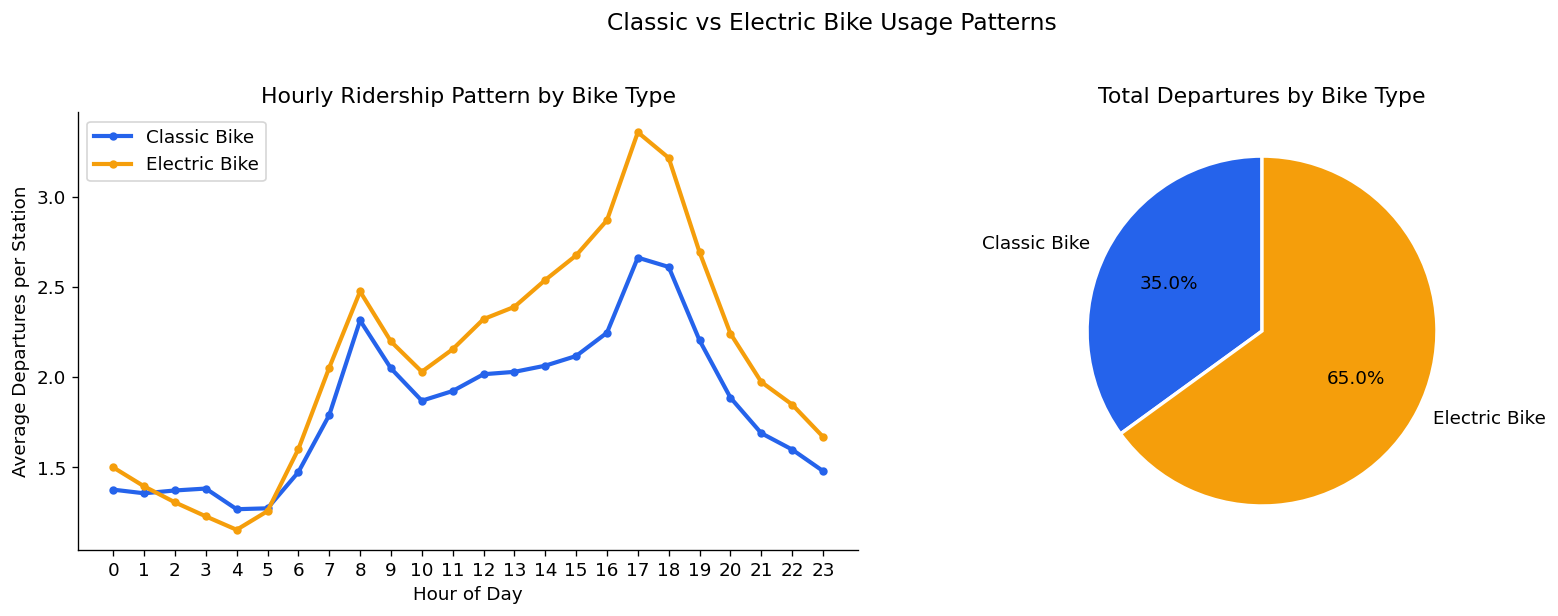

In [9]:
# initialize dataframe, plots
bike_hourly = (df.groupby(['hour_of_day', 'rideable_type'])['departures']
			.mean()
			.reset_index())
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# plot hourly pattern by bike type
for bike_type, color in [('classic_bike', COLORS['primary']), ('electric_bike', COLORS['secondary'])]:
	data = bike_hourly[bike_hourly['rideable_type'] == bike_type]
	ax[0].plot(data['hour_of_day'], data['departures'],
        label=bike_type.replace('_', ' ').title(),
        color=color, linewidth=2.5, marker='o', markersize=4)

ax[0].set_title('Hourly Ridership Pattern by Bike Type')
ax[0].set_xlabel('Hour of Day')
ax[0].set_ylabel('Average Departures per Station')
ax[0].set_xticks(range(0, 24))
ax[0].legend()

# plot total share by bike type
bike_totals = df.groupby('rideable_type')['departures'].sum()
ax[1].pie(bike_totals.values, labels=[t.replace('_', ' ').title() for t in bike_totals.index],
        colors=[COLORS['primary'], COLORS['secondary']],
        autopct='%1.1f%%', startangle = 90,
        wedgeprops=dict(edgecolor='white', linewidth=2))
ax[1].set_title('Total Departures by Bike Type')

# configure plot, display
plt.suptitle('Classic vs Electric Bike Usage Patterns', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/classic_vs_electric.png', bbox_inches='tight')
plt.show()


## 2.9: Trip Duration Distribution

Distribution of average trip duration per station per hour. Median of 10.3 minutes confirms CitiBike's primary role as a short-distance mode of transport. 99.2% of observations fall below 60 minutes, so it serves as a reasonable cutoff

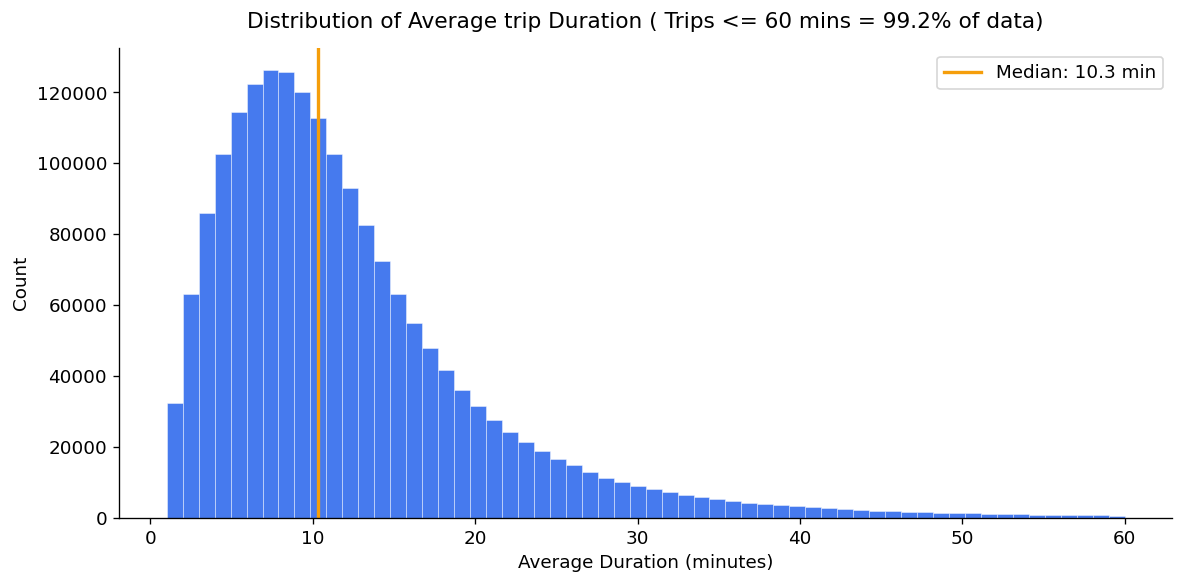

In [10]:
# initialize dataframes (clipping at 60 min trips for readability, but noting what percent are longer)
under_60 = df_model[df_model['avg_duration_min'] <= 60]
pct_under_60 = (len(under_60) / len(df_model)) * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(under_60['avg_duration_min'], bins=60, color=COLORS['primary'], edgecolor='white', linewidth=0.3, alpha=0.85)
ax.axvline(df_model['avg_duration_min'].median(), color=COLORS['secondary'], linewidth=2,
		label=f"Median: {df_model['avg_duration_min'].median():.1f} min")
ax.set_title(f"Distribution of Average trip Duration ( Trips <= 60 mins = {pct_under_60:.1f}% of data)",
    fontsize=13, pad=12)
ax.set_xlabel('Average Duration (minutes)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/eda/trip_duration_distribution.png', bbox_inches='tight')
plt.show()

## 2.10: Station Flow Imbalance

Net flow (departures minus arrivals) per station ranked to identify the issue of rebalancing stations. Net arrival stations reach imbalances 6x larger than net departure stations — concentrated at leisure destinations rather than residential origins. Pier 61 at Chelsea Piers is the most extreme arrival sink in the network.

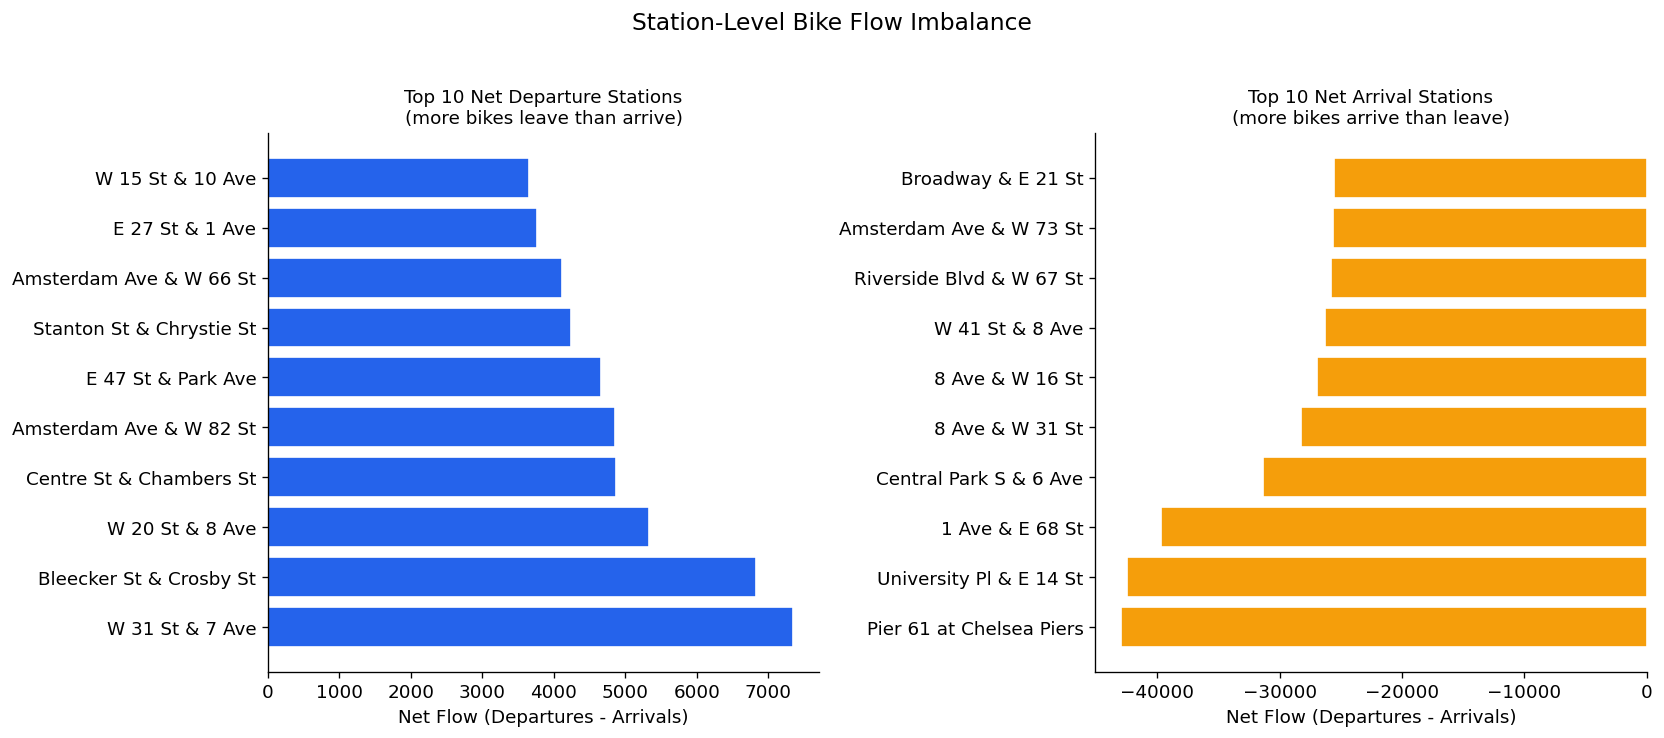

In [11]:
# initialize dataframe
station_balance = (df_model.groupby('start_station_name')
				.agg(total_departures=('ride_count', 'sum'),
					total_arrivals=('arrivals', 'sum'))
				.reset_index())

station_balance['net_flow'] = (station_balance['total_departures'] - station_balance['total_arrivals'])

# get top 10 net sources and sinks
top_sources = station_balance.nlargest(10, 'net_flow') 
top_sinks = station_balance.nsmallest(10, 'net_flow')

# initialize, set up plots
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].barh(top_sources['start_station_name'], top_sources['net_flow'], color=COLORS['primary'], edgecolor='white')
ax[0].set_title('Top 10 Net Departure Stations\n(more bikes leave than arrive)', fontsize=11)
ax[0].set_xlabel('Net Flow (Departures - Arrivals)')
ax[1].barh(top_sinks['start_station_name'], top_sinks['net_flow'], color=COLORS['secondary'], edgecolor='white')
ax[1].set_title('Top 10 Net Arrival Stations\n(more bikes arrive than leave)', fontsize=11)
ax[1].set_xlabel('Net Flow (Departures - Arrivals)')

# configure and show plots
plt.suptitle('Station-Level Bike Flow Imbalance', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/station_flow_imbalance.png', bbox_inches='tight')
plt.show()

## 2.10: Correlation Heatmap

Pairwise correlation matrix between all numeric features and the target (ride_count). No single feature strongly correlates with ridership - drives home the idea that demand is driven by a combination of factors. Some of the other pairwise correlations here check out (is_weekend and day_of_week, month and temperature)

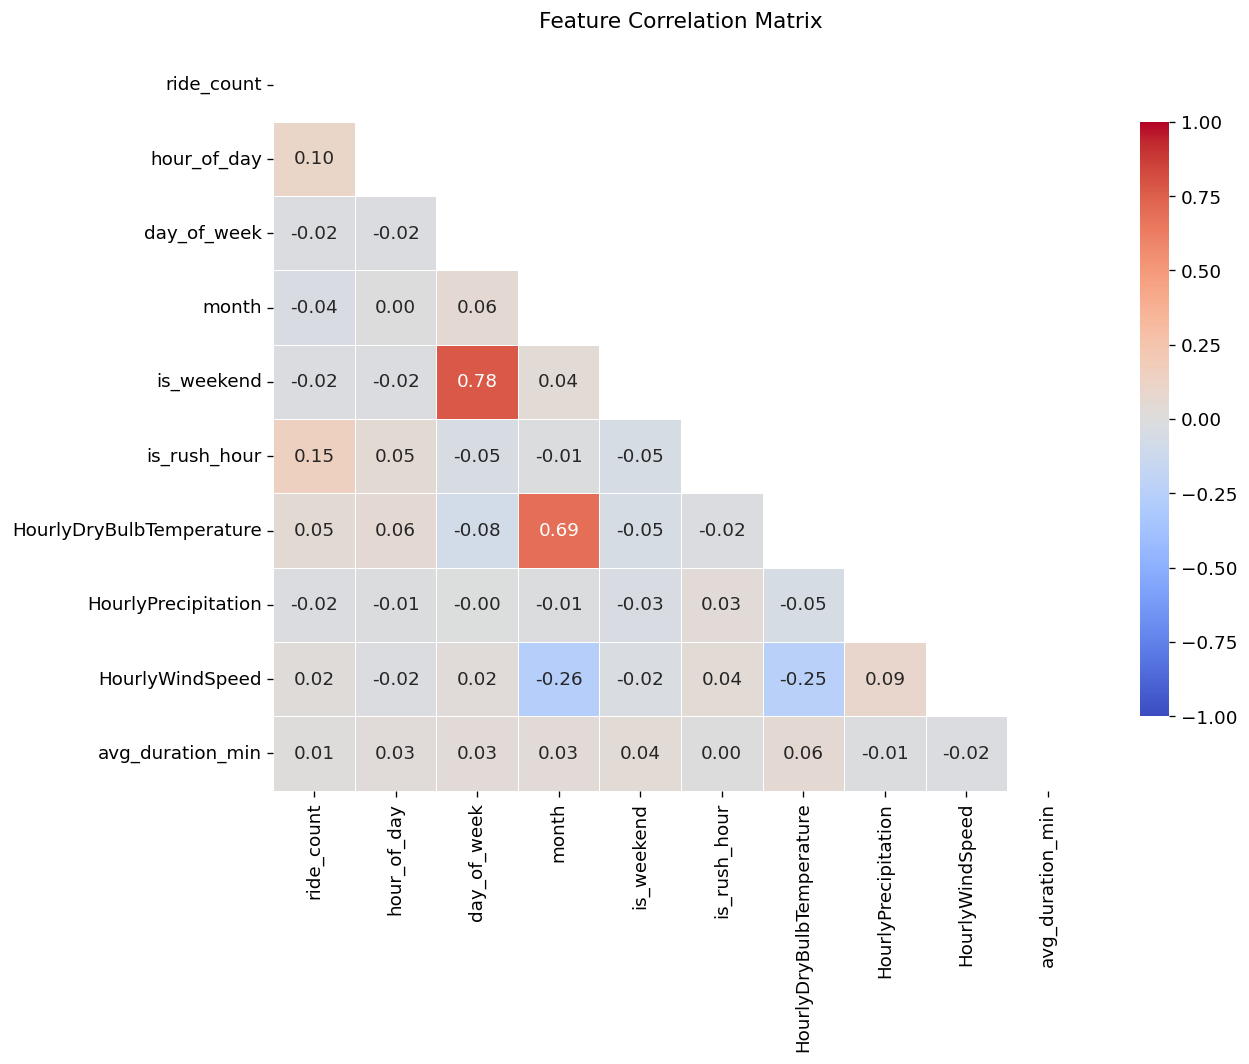

In [12]:
numeric_cols = [
    'ride_count', 'hour_of_day', 'day_of_week', 'month', 'is_weekend', 
	'is_rush_hour', 'HourlyDryBulbTemperature', 'HourlyPrecipitation', 
	'HourlyWindSpeed', 'avg_duration_min'
]

# get correlation matrix for numeric features
corr = df_model[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(11 ,9))
mask = np.triu(np.ones_like(corr, dtype=bool)) # upper triangle mask
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=ax,
        linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=13, pad=12)

plt.tight_layout()
plt.savefig('../figures/eda/correlation_heatmap.png', bbox_inches='tight')
plt.show()


## 2.11: Station Spatial Map

Geographic overview of station ridership concentration. Dot size encodes total traffic volume, color encodes hourly ride count. Manhattan is immediately a visual focal point.

Station lat range: 40.6334 - 40.8863
Station lng range: -74.0711 - -73.8467


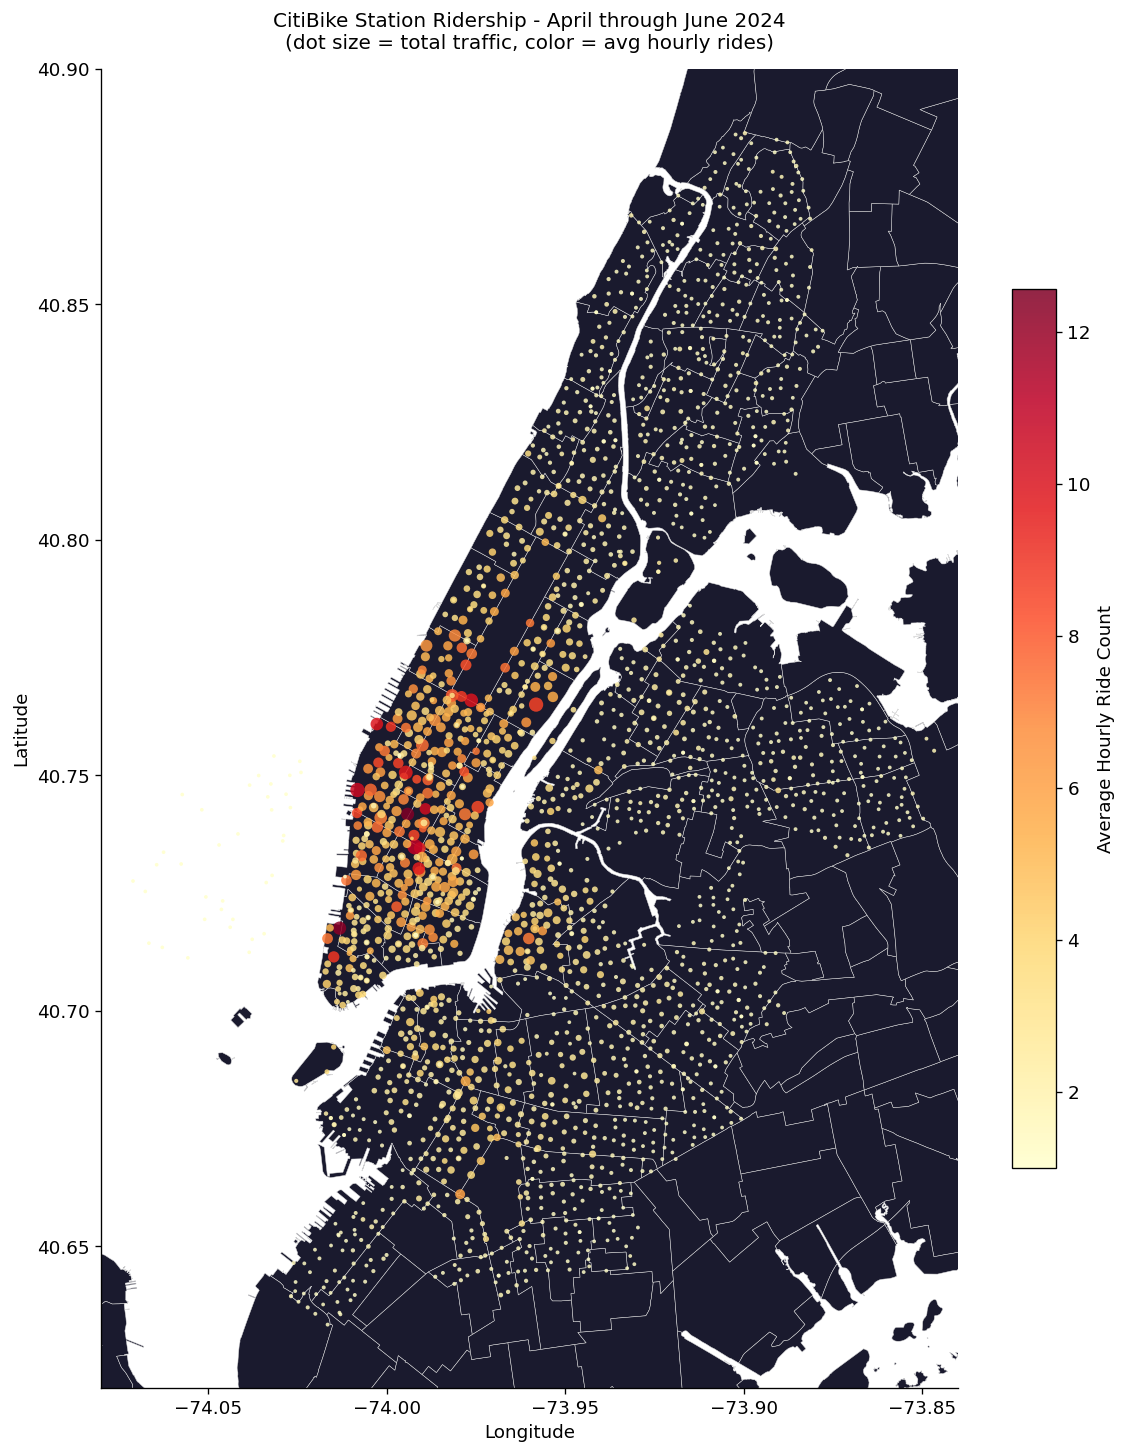

In [13]:
fig, ax = plt.subplots(figsize=(10, 13))

# plot nta boundaries as light background
nta.plot(ax=ax, color="#1a1a2e", edgecolor='#dddddd', linewidth=0.3)

# verify boundaries of latitude and longitude ranges of points
print(f"Station lat range: {stations_geo['start_lat'].min():.4f} - {stations_geo['start_lat'].max():.4f}")
print(f"Station lng range: {stations_geo['start_lng'].min():.4f} - {stations_geo['start_lng'].max():.4f}")

# plot stations
scatter = ax.scatter(
    stations_geo['start_lng'],
    stations_geo['start_lat'],
    c=stations_geo['avg_ride_count'],
    cmap='YlOrRd',
    s=stations_geo['total_traffic'] / stations_geo['total_traffic'].max() * 80 + 5, # optimal scaling parameter that i've found
    alpha=0.85,
    edgecolors='none'
)
plt.colorbar(scatter, ax=ax, label='Average Hourly Ride Count', shrink=0.6)
ax.set_title('CitiBike Station Ridership - April through June 2024\n'
        '(dot size = total traffic, color = avg hourly rides)', fontsize=12, pad=12)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
# prevent out of bounds plotting just in case
ax.set_xlim(-74.08, -73.84)
ax.set_ylim(40.62,40.90)

plt.tight_layout()
plt.savefig('../figures/eda/station_spatial_map.png', bbox_inches='tight')
plt.show()


## 2.12: Patterns with School Proximity

Hourly ridership pattern split by whether stations are within 300 meters of a school (50% of stations). School adjacent stations show consistently lower ridership - likely because of those stations being concentrated in lower-ridership outer boroughs. Monthly analysis confirms no school-year-ending effect on June ridership patterns

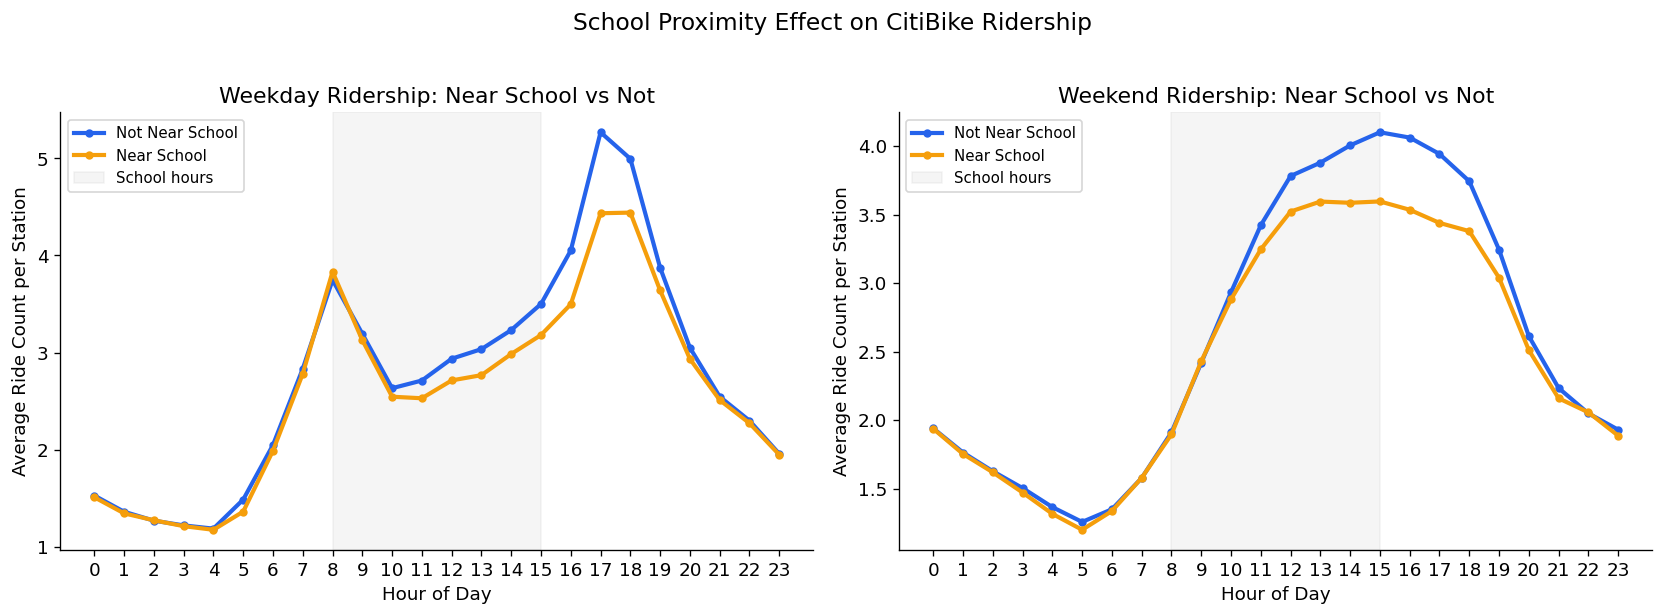

In [14]:
school_hourly = (df_model.merge(          
        station_lookup[['start_station_id', 'near_school']],
        on='start_station_id', how='left')
    .groupby(['near_school', 'hour_of_day', 'is_weekend'])
    .agg(avg_rides=('ride_count', 'mean'))
    .reset_index()
)

fig, ax = plt.subplots(1, 2, figsize = (14, 5))
for ax, is_weekend, title in [(ax[0], 0, 'Weekday'), (ax[1], 1, 'Weekend')]:
    subset = school_hourly[school_hourly['is_weekend'] == is_weekend]
    for near, color, label in [(0, COLORS['primary'], 'Not Near School'), (1, COLORS['secondary'], 'Near School')]:
        data = subset[subset['near_school'] == near]
        ax.plot(data['hour_of_day'], data['avg_rides'],
            color=color, linewidth=2.5, label=label, marker='o', markersize=4)

    ax.axvspan(8, 15, alpha=0.08, color='gray', label='School hours')
    ax.set_title(f'{title} Ridership: Near School vs Not')
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Average Ride Count per Station')
    ax.set_xticks(range(0, 24))
    ax.legend(fontsize=9)

plt.suptitle('School Proximity Effect on CitiBike Ridership', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/school_proximity_ridership.png', bbox_inches='tight')
plt.show()